## Data Processing

### Training/Test Data
- **Labels**: Bioinformatics expert annotations (`del` vs `WT`)
- **Features**: Clinical markers + Chromosome 10 bin counts (PTEN gene region)

### Prospective Validation Data
- **Labels**: H-Score from immunohistochemistry (IHC) staining
- **Cohorts**: Validation A, B, and C

## Feature Description

### Clinical Features (2)
- **TCC GEPADO**: Tumor Cell Content percentage
- **FC PTEN Illumina**: Fold Change of PTEN gene expression

### Genomic Features (39)
- **chr10.136_NC to chr10.174_NC**: Normalized counts for chromosome 10 bins covering PTEN gene region

## Label Mapping

### Training Data
- **del** (deletion) → 0
- **WT** (wild type) → 1

### Validation Data (H-Score based)
- **H-Score < 25** → `del` (deletion)
- **H-Score ≥ 90** → `WT` (wild type)  
- **25 ≤ H-Score < 90** → `grey` (intermediate)


In [1]:
%load_ext autoreload
%autoreload 2
%cd ../../..

/home/hal/workspace/clinical-ai-guardrails


/home/hal/workspace/clinical-ai-guardrails/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
from pathlib import Path
from clinical_ai_guardrails.config import (
    DATASET_PATH, BIN_COLUMNS, TEST_COL,
    TRAIN_COLUMNS, TARGET_COLUMNS, LABEL_MAP, BASE_DIR
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

sns.set_style('ticks')

print(f"- Dataset path: {DATASET_PATH.relative_to(BASE_DIR.parent)}")

- Dataset path: clinical-ai-guardrails/data/annonymized/train_val_pids_annon.csv


## 1. Open Training and Test Data

In [9]:
dataset = pd.read_csv(DATASET_PATH.resolve())
print(f"Dataset shape: {dataset.shape}")
print(f"Count of columns: {len(dataset.columns)}")

LABEL = 'Bioinf called as'
print(f"\nTarget label: {LABEL}")
print(f"Available labels: {dataset[LABEL].unique()}")

# --- Split dataset
train_df = dataset[dataset[TEST_COL] == 0]
train_X = train_df[TRAIN_COLUMNS]
train_y = train_df[TARGET_COLUMNS][LABEL].map(LABEL_MAP[LABEL])

test_df = dataset[dataset[TEST_COL] == 1]
test_X = test_df[TRAIN_COLUMNS]
test_y = test_df[TARGET_COLUMNS][LABEL].map(LABEL_MAP[LABEL])
    
# Basic dataset info
print(f"\nDataset Overview:")
print(f"• Total samples: {len(dataset)}")
print(f"• Training samples: {len(dataset[dataset[TEST_COL] == 0])}")
print(f"• Test samples: {len(dataset[dataset[TEST_COL] == 1])}")

Dataset shape: (118, 56)
Count of columns: 56

Target label: Bioinf called as
Available labels: ['del' 'WT' nan]

Dataset Overview:
• Total samples: 118
• Training samples: 42
• Test samples: 16


In [10]:
print(f"Train set shape: {train_X.shape}")
print(f"Test set shape: {test_X.shape}")

train_counts = train_y.value_counts()
test_counts = test_y.value_counts()

print(f"\nTraining Labels Distribution:")
print(f"  • Deletion (0): {train_counts.get(0, 0)} samples ({train_counts.get(0, 0)/len(train_y)*100:.0f}%)")
print(f"  • Wild Type (1): {train_counts.get(1, 0)} samples ({train_counts.get(1, 0)/len(train_y)*100:.0f}%)")

print(f"\nTest Labels Distribution:")
print(f"  • Deletion (0): {test_counts.get(0, 0)} samples ({test_counts.get(0, 0)/len(test_y)*100:.0f}%)")
print(f"  • Wild Type (1): {test_counts.get(1, 0)} samples ({test_counts.get(1, 0)/len(test_y)*100:.0f}%)")

Train set shape: (42, 41)
Test set shape: (16, 41)

Training Labels Distribution:
  • Deletion (0): 21 samples (50%)
  • Wild Type (1): 21 samples (50%)

Test Labels Distribution:
  • Deletion (0): 12 samples (75%)
  • Wild Type (1): 4 samples (25%)


In [13]:
print(f"Saving training and test datasets...")
train_dir = Path(BASE_DIR) / 'data' / 'ready' / 'train'
train_dir.mkdir(parents=True, exist_ok=True)

train_X.to_csv(train_dir / 'train.csv', index=False)
test_X.to_csv(train_dir / 'test.csv', index=False)
train_y.to_csv(train_dir / 'train_labels.csv', index=False)
test_y.to_csv(train_dir / 'test_labels.csv', index=False)

print(f"Files saved to: ./{train_dir.relative_to(BASE_DIR)}")

Saving training and test datasets...
Files saved to: ./data/ready/train


## 2. Open prospective validation data

Loading Prospective Validation Data...
Dataset shape: (74, 54)
Validation cohorts: ['A' 'B' 'C']


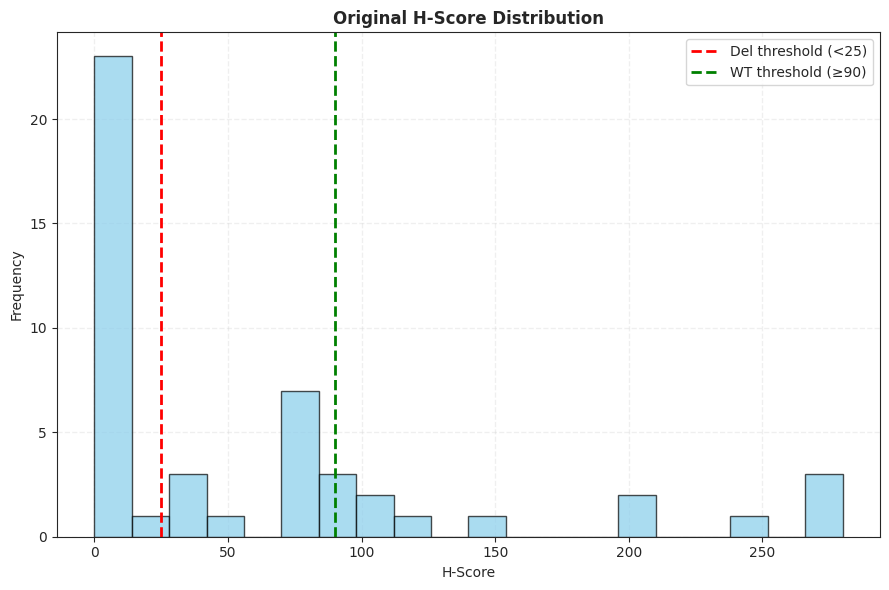


H-Score Mapping Rules:
  • H-Score < 25 → 'del' (deletion)
  • H-Score ≥ 90 → 'WT' (wild type)
  • 25 ≤ H-Score < 90 → 'grey' (intermediate)


In [14]:
print("Loading Prospective Validation Data...")

pros_path = Path(BASE_DIR) / 'data' / 'annonymized' / 'prosp_pids_annon.csv'
pros_df = pd.read_csv(pros_path)
VAL_LABEL = 'H-Score'  # IHC staining

print(f"Dataset shape: {pros_df.shape}")
print(f"Validation cohorts: {pros_df['Validation cohort'].unique()}")

# --- H-Score distribution
fig, (ax1) = plt.subplots(1, 1, figsize=(9, 6))
ax1.hist(pros_df[VAL_LABEL], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(25, color='red', linestyle='--', linewidth=2, label='Del threshold (<25)')
ax1.axvline(90, color='green', linestyle='--', linewidth=2, label='WT threshold (≥90)')
ax1.set_xlabel('H-Score')
ax1.set_ylabel('Frequency')
ax1.set_title('Original H-Score Distribution', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

print(f"\nH-Score Mapping Rules:")
print(f"  • H-Score < 25 → 'del' (deletion)")
print(f"  • H-Score ≥ 90 → 'WT' (wild type)")
print(f"  • 25 ≤ H-Score < 90 → 'grey' (intermediate)")

Splitting Prospective Validation Data by Cohorts...
Prospective validation A set shape: (9, 41)
Prospective validation B set shape: (65, 41)


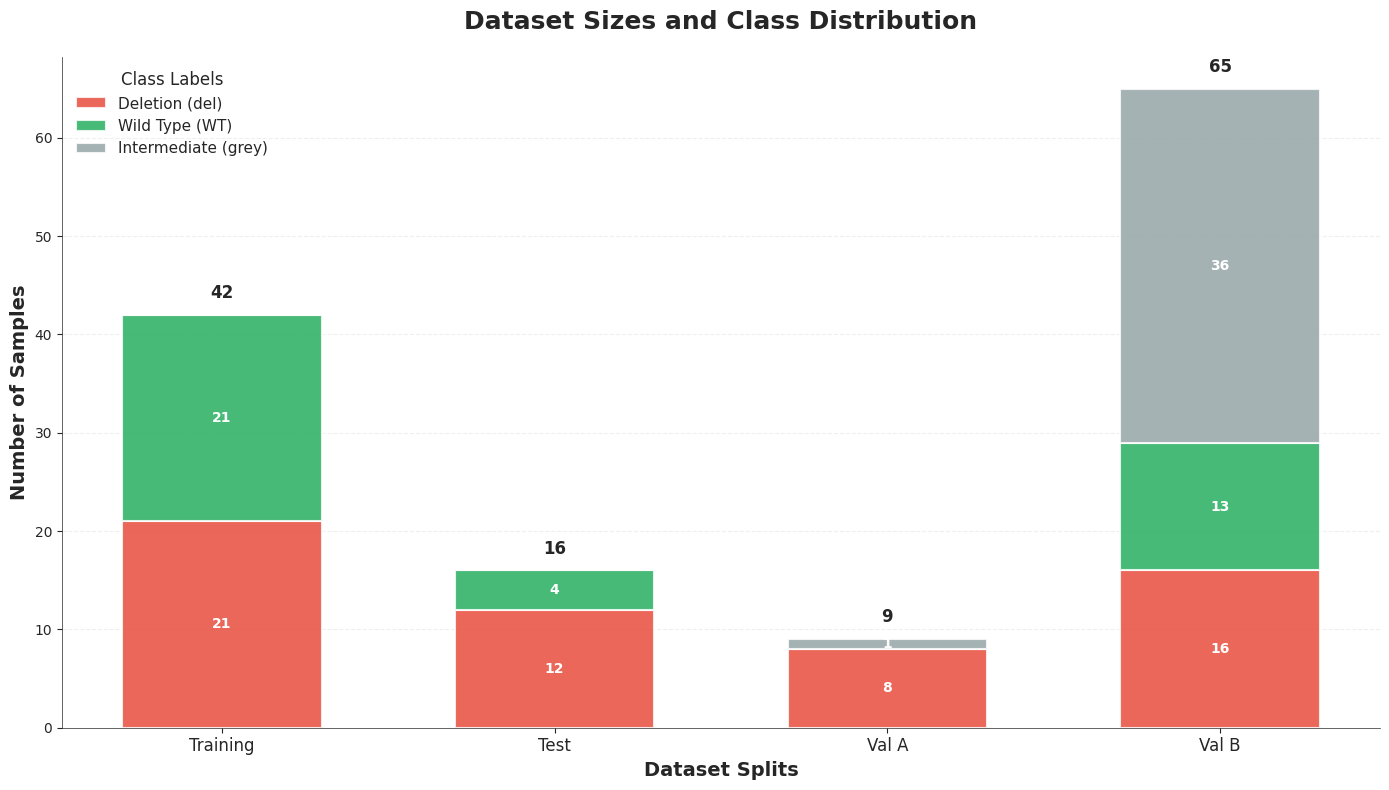


Validation A Labels Distribution:
  • del: 8 samples (88.9%)
  • grey: 1 samples (11.1%)

Validation B Labels Distribution:
  • grey: 36 samples (55.4%)
  • del: 16 samples (24.6%)
  • WT: 13 samples (20.0%)


In [15]:

print("Splitting Prospective Validation Data by Cohorts...")

pros_val_A = pros_df[pros_df['Validation cohort'] == 'A']
val_A_X = pros_val_A[TRAIN_COLUMNS]
val_A_y = pros_val_A[TARGET_COLUMNS][VAL_LABEL].map(lambda x: 'del' if x < 25 else ('WT' if x >= 90 else 'grey'))

pros_val_B = pros_df[pros_df['Validation cohort'].isin(['B', 'C'])]
val_B_X = pros_val_B[TRAIN_COLUMNS]
val_B_y = pros_val_B[TARGET_COLUMNS][VAL_LABEL].map(lambda x: 'del' if x < 25 else ('WT' if x >= 90 else 'grey'))

print(f"Prospective validation A set shape: {val_A_X.shape}")
print(f"Prospective validation B set shape: {val_B_X.shape}")

# --- Data for plotting
train_counts = train_y.value_counts()
test_counts = test_y.value_counts()
val_A_counts = val_A_y.value_counts()
val_B_counts = val_B_y.value_counts()

# Prepare data for stacked bar chart
datasets = ['Training', 'Test', 'Val A', 'Val B']
del_counts = [
    train_counts.get(0, 0),
    test_counts.get(0, 0), 
    val_A_counts.get('del', 0),
    val_B_counts.get('del', 0)
]
wt_counts = [
    train_counts.get(1, 0),
    test_counts.get(1, 0),
    val_A_counts.get('WT', 0),
    val_B_counts.get('WT', 0)
]
grey_counts = [
    0, 0,  # Training and Test don't have grey labels
    val_A_counts.get('grey', 0),
    val_B_counts.get('grey', 0)
]

# --- Stacked Bar Plot
fig, ax = plt.subplots(figsize=(14, 8))
colors = {
    'del': '#E74C3C',    # Red for deletion
    'WT': '#27AE60',     # Green for wild type  
    'grey': '#95A5A6'    # Grey for intermediate
}

width = 0.6
x_pos = np.arange(len(datasets))

# Bars
bars1 = ax.bar(x_pos, del_counts, width, label='Deletion (del)', 
               color=colors['del'], alpha=0.85, edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x_pos, wt_counts, width, bottom=del_counts, label='Wild Type (WT)', 
               color=colors['WT'], alpha=0.85, edgecolor='white', linewidth=1.5)
bars3 = ax.bar(x_pos, grey_counts, width, bottom=np.array(del_counts) + np.array(wt_counts), 
               label='Intermediate (grey)', color=colors['grey'], alpha=0.85, edgecolor='white', linewidth=1.5)

ax.set_xlabel('Dataset Splits', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=14, fontweight='bold')
ax.set_title('Dataset Sizes and Class Distribution', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(datasets, fontsize=12)

ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

legend = ax.legend(loc='upper left', frameon=False, fancybox=False, shadow=False, 
                   fontsize=11, title='Class Labels', title_fontsize=12)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)

totals = np.array(del_counts) + np.array(wt_counts) + np.array(grey_counts)
for i, total in enumerate(totals):
    ax.text(i, total + max(totals) * 0.02, f'{total}', 
            ha='center', va='bottom', fontweight='bold', fontsize=12)

for i in range(len(datasets)):
    total = totals[i]
    if total > 0:
        if del_counts[i] > 0:
            ax.text(i, del_counts[i]/2, f'{del_counts[i]}', 
                       ha='center', va='center', fontweight='bold', 
                       color='white', fontsize=10)
        
        if wt_counts[i] > 0:
            ax.text(i, del_counts[i] + wt_counts[i]/2, f'{wt_counts[i]}', 
                    ha='center', va='center', fontweight='bold', 
                    color='white', fontsize=10)
        
        if grey_counts[i] > 0:
            ax.text(i, del_counts[i] + wt_counts[i] + grey_counts[i]/2, f'{grey_counts[i]}', 
                   ha='center', va='center', fontweight='bold', 
                   color='white', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nValidation A Labels Distribution:")
for category, count in val_A_counts.items():
    percentage = count / len(val_A_y) * 100
    print(f"  • {category}: {count} samples ({percentage:.1f}%)")

print(f"\nValidation B Labels Distribution:")
for category, count in val_B_counts.items():
    percentage = count / len(val_B_y) * 100
    print(f"  • {category}: {count} samples ({percentage:.1f}%)")

grey_A = val_A_counts.get('grey', 0)
grey_B = val_B_counts.get('grey', 0)


In [17]:
print("Saving Prospective Validation Datasets...")

pros_dir = Path(BASE_DIR) / 'data' / 'ready' / 'prospective'
pros_dir.mkdir(parents=True, exist_ok=True)

val_A_X.to_csv(pros_dir / 'val_A.csv', index=False)
val_A_y.to_csv(pros_dir / 'val_A_labels.csv', index=False)
val_B_X.to_csv(pros_dir / 'val_B.csv', index=False)
val_B_y.to_csv(pros_dir / 'val_B_labels.csv', index=False)

print(f"\nFiles saved to: ./{pros_dir.relative_to(BASE_DIR)}")


Saving Prospective Validation Datasets...

Files saved to: ./data/ready/prospective
